In [64]:
import pandas as pd 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import joblib 
import numpy as np
from catboost import CatBoostRegressor

In [65]:
import pandas as pd 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import joblib 
import numpy as np
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor


In [66]:
df = pd.read_csv("medical_insurance.csv")
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0


In [67]:
df.columns

Index(['person_id', 'age', 'sex', 'region', 'urban_rural', 'income',
       'education', 'marital_status', 'employment_status', 'household_size',
       'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year',
       'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
       'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
       'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years',
       'policy_changes_last_2yrs', 'provider_quality', 'risk_score',
       'annual_medical_cost', 'annual_premium', 'monthly_premium',
       'claims_count', 'avg_claim_amount', 'total_claims_paid',
       'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd',
       'cardiovascular_disease', 'cancer_history', 'kidney_disease',
       'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count',
       'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
       'proc_lab_count', 'is_high_risk', 'had_major_procedure'],
      

In [68]:
df.dtypes

person_id                        int64
age                              int64
sex                                str
region                             str
urban_rural                        str
income                         float64
education                          str
marital_status                     str
employment_status                  str
household_size                   int64
dependents                       int64
bmi                            float64
smoker                             str
alcohol_freq                       str
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                          str
network_tier                       str
deductible                       int64
copay                    

In [69]:
df.isnull().sum()

person_id                          0
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
p

In [70]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0


In [71]:
df["alcohol_freq"].nunique()

3

In [72]:
df["alcohol_freq"] = df["alcohol_freq"].fillna(df["alcohol_freq"].mode()[0] )


In [73]:
df.isnull().sum()

person_id                      0
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_med

In [74]:
df.drop("person_id", axis = 1, inplace = True )

In [75]:
df = pd.get_dummies(df, drop_first= True )

In [76]:
df.dtypes

age                        int64
income                   float64
household_size             int64
dependents                 int64
bmi                      float64
                          ...   
plan_type_POS               bool
plan_type_PPO               bool
network_tier_Gold           bool
network_tier_Platinum       bool
network_tier_Silver         bool
Length: 72, dtype: object

In [77]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [78]:
df.dtypes

age                        int64
income                   float64
household_size             int64
dependents                 int64
bmi                      float64
                          ...   
plan_type_POS              int64
plan_type_PPO              int64
network_tier_Gold          int64
network_tier_Platinum      int64
network_tier_Silver        int64
Length: 72, dtype: object

In [79]:
X = df.drop([
    "annual_medical_cost",
    "annual_premium",
    "monthly_premium",
    "total_claims_paid",
    "avg_claim_amount",
    "claims_count"
], axis=1)

y = df["annual_medical_cost"]

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)
X_train.shape
y_train.shape

(80000,)

In [81]:
corr = df.corr(numeric_only=True)

print(
    corr["annual_medical_cost"]
    .sort_values(ascending=False)
    .head(15)
)

annual_medical_cost            1.000000
monthly_premium                0.965416
annual_premium                 0.965415
total_claims_paid              0.739402
avg_claim_amount               0.632996
risk_score                     0.305971
chronic_count                  0.296720
is_high_risk                   0.251923
days_hospitalized_last_3yrs    0.230246
hospitalizations_last_3yrs     0.208640
visits_last_year               0.195631
claims_count                   0.179082
hypertension                   0.154309
had_major_procedure            0.148292
systolic_bp                    0.145070
Name: annual_medical_cost, dtype: float64


In [82]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

In [83]:
model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)

In [84]:
y_pred = model.predict(X_test)

In [85]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE : ", round(mae, 2))

MAE :  1767.7


In [86]:
mse = mean_squared_error(y_test,y_pred)
print("MSE : ", round(mse , 2))

MSE :  8085935.59


In [87]:
rmse = np.sqrt(mse)
print("RMSE : ", round(rmse, 2))

RMSE :  2843.58


In [88]:
r2 = r2_score(y_test, y_pred)
print("R2 SCORE : ", round(r2, 2))

R2 SCORE :  0.18


In [89]:
print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R2 Score :", round(r2, 4))
df["annual_medical_cost"].describe()

MAE : 1767.7
RMSE : 2843.58
R2 Score : 0.1783


count    100000.000000
mean       3009.451907
std        3127.462822
min          55.550000
25%        1175.117500
50%        2082.575000
75%        3707.957500
max       65724.900000
Name: annual_medical_cost, dtype: float64

In [90]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    ).head(15)
)

                        Feature  Importance
7   days_hospitalized_last_3yrs   19.397966
19                chronic_count   12.662493
18                   risk_score   12.638785
57                 smoker_Never    8.411274
5              visits_last_year    6.602393
6    hospitalizations_last_3yrs    4.100117
4                           bmi    3.623209
0                           age    3.283603
12                        hba1c    2.235095
1                        income    2.080398
56                smoker_Former    1.991936
9                   systolic_bp    1.952122
11                          ldl    1.738313
10                 diastolic_bp    1.663915
17             provider_quality    1.553134


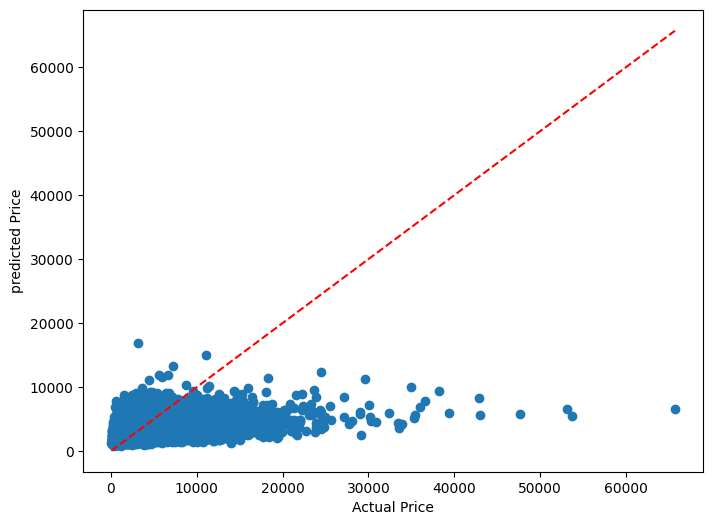

In [91]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Price")
plt.ylabel("predicted Price")
plt.show()

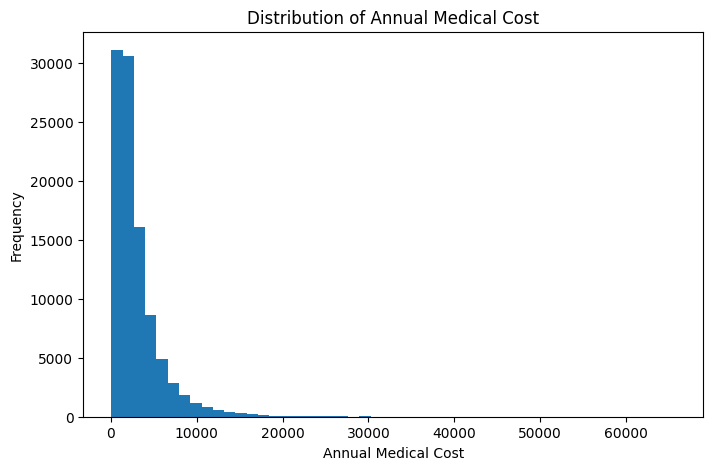

In [92]:
plt.figure(figsize=(8,5))
plt.hist(df["annual_medical_cost"], bins=50)
plt.xlabel("Annual Medical Cost")
plt.ylabel("Frequency")
plt.title("Distribution of Annual Medical Cost")
plt.show()

In [93]:
joblib.dump(model, "medical_insurance_model.pkl")

['medical_insurance_model.pkl']